# PART THREE: 

• CONTEXT: Develop a clickable GUI [desk application or web service application] which can automate Part I & II of this
project.

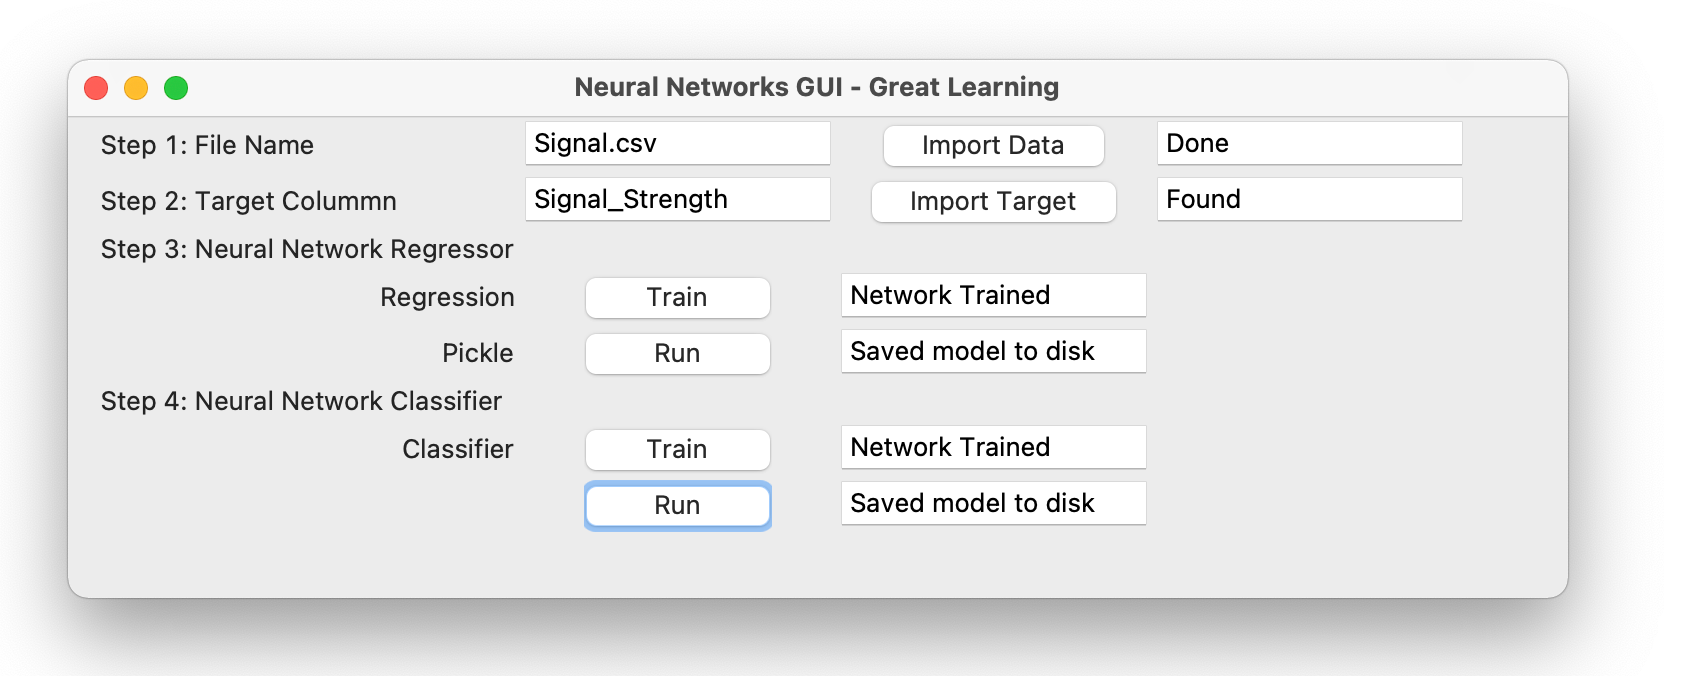

In [28]:
#import library

import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display, Markdown, clear_output
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Normalizer, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier, KerasRegressor
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.utils import to_categorical

In [29]:
 label_header = widgets.Label(
                  'Neural Networks GUI - Great Learning',
                  layout = Layout(width='800px',display="flex",justify_content="center"),                
               )

text = widgets.Text(
       description = '',
       value = 'Enter file name with file path'
        )

text1 = widgets.Text(
       description = '',
       
       )

label_filename = widgets.Label(
                  'File Name',
                  layout = Layout(width='100px',display="flex",justify_content="flex-start")
                )

label_target = widgets.Label(
                  'Target Column',
                  layout = Layout(width='100px',display="flex",justify_content="flex-start")
                )

label = widgets.Label(
        'Neural Network Regressor',
        )

labelc = widgets.Label(
        'Neural Network Classifier',
        )


label_regressor = widgets.Label(
        'Regression',
        layout = Layout(width='100px',display="flex",justify_content="flex-end")
        )
label_regressor_pickle = widgets.Label(
        'Pickle',
        layout = Layout(width='100px',display="flex",justify_content="flex-end")
        )

label_classifier = widgets.Label(
        'Classifier',
        layout = Layout(width='100px',display="flex",justify_content="flex-end")
        )

label_classifier_pickle = widgets.Label(
        'Pickle',
        layout = Layout(width='100px',display="flex",justify_content="flex-end")
        )

text_import = widgets.Text(
        value='',
        )

text_target = widgets.Text(
        value='',
        )

text_regression_train = widgets.Text(
        value='',
        )

text_regression_pickle = widgets.Text(
        value='',
        )

text_classifier_train = widgets.Text(
        value='',
        )

text_classifier_pickle = widgets.Text(
        value='',
        )

button = widgets.Button(
        description='Import Data',
        )


button_target = widgets.Button(
        description='Import Target',
        )

button_regression_train = widgets.Button(
        description='Train',
        )

button_regression_pickle = widgets.Button(
        description='Run',
        )

button_classifier_train = widgets.Button(
        description='Train',
        )

button_classifier_pickle = widgets.Button(
        description='Run',
        )

out = widgets.Output()
out1 = widgets.Output()

In [30]:
 def on_button_clicked(_):
      # "linking function with output"
      global df
      with out:
          # what happens when we press the button
        
          df = pd.read_csv(text.value)
          clear_output()
          text_import.value="Done"
      return df 

def on_button_target_clicked(_):
      # "linking function with output"
      with out1:
          # what happens when we press the button
          if text1.value in df.columns:
              clear_output()
              text_target.value = 'Found'

def on_button_target_clicked(_):
      # "linking function with output"
      with out1:
          # what happens when we press the button
          
              clear_output()
              text_target.value = 'Found'


def on_button_regression_train_clicked(_):
    global regmodel
    with out1:
       # global regmodel
        X = df.drop(text1.value, axis=1)
        y = df[text1.value]
        clear_output()
        text_regression_train.value = " 20% Training Inprogress. Please wait..."
        
        X = X.astype('float32')
        y = y.astype('float32')

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=1)
        clear_output()
        text_regression_train.value = "40% Training Inprogress. Please wait..."
        
        normal = MinMaxScaler()
        scaledXtrain = normal.fit_transform(X_train)
        scaledXtest = normal.transform(X_test)

        clear_output()
        text_regression_train.value = "60% Training Inprogress. Please wait..."

        #Initialize Sequential Graph (model)
        regmodel = tf.keras.Sequential()
        
        #Add Dense layer for prediction - Keras declares weights and bias automatically
        regmodel.add(tf.keras.layers.Dense(6, input_dim=11, kernel_initializer='normal', activation='relu'))
        regmodel.add(tf.keras.layers.Dense(1, activation='linear'))

        #Compile the model - add Loss and Gradient Descent optimizer
        regmodel.compile(optimizer=keras.optimizers.Adam(),  loss='mse', metrics=['mse'])

        clear_output()
        text_regression_train.value = "80% Training Inprogress. Please wait..."

        regmodel.fit(scaledXtrain, y_train,
                validation_data=(scaledXtest, y_test), 
               epochs=100,
                batch_size = 5
                )
        clear_output()
        text_regression_train.value = "Network Trained"
    return regmodel

def on_button_regression_pickle_clicked(_):
   with out1:
      regmodel.save_weights('signal_regressor.h5')
      clear_output()
      text_regression_pickle.value = "Saved model to disk"

def on_button_classifier_train_clicked(_):
    with out1:
        global clsmodel
        # Split independed and depended variable
        X = df.drop(text1.value, axis=1)
        y = df[text1.value]

        clear_output()
        text_classifier_train.value = "20% Training inprogress, please wait..."
        
        X = X.astype('float32')
        y = y.astype('int32')

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=1)
        clear_output()
        text_classifier_train.value = "40% Training inprogress, please wait..."
        
        y_train = to_categorical(y_train, num_classes=9)
        y_test = to_categorical(y_test, num_classes=9, dtype='int32')

        normal = MinMaxScaler()
        X_train = normal.fit_transform(X_train)
        X_test = normal.transform(X_test)

        clear_output()
        text_classifier_train.value = "60% Training inprogress, please wait..."
        
        clsmodel = tf.keras.Sequential()

        #Add Dense layer for prediction - Keras declares weights and bias automatically
        clsmodel.add(tf.keras.layers.Dense(20, input_dim=11, activation='relu'))
        clsmodel.add(tf.keras.layers.Dense(15, input_dim=11, activation='relu'))
        clsmodel.add(tf.keras.layers.Dense(9, activation='softmax'))
        #Compile the model
        clsmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        clear_output()
        text_classifier_train.value = "80% Training inprogress, please wait..."
        
        clsmodel.fit(X_train, y_train,
                  validation_data=(X_test, y_test), 
                  epochs=100,
                  batch_size = 20
                )
        clear_output()
        text_classifier_train.value = "Network Trained"
    return clsmodel

def on_button_classifier_pickle_clicked(_):
   with out1:
      clsmodel.save_weights('signal_classifier.h5')
      clear_output()
      text_classifier_pickle.value = "Saved model to disk"

In [31]:
button.on_click(on_button_clicked)
button_target.on_click(on_button_target_clicked)
button_regression_train.on_click(on_button_regression_train_clicked)
button_regression_pickle.on_click(on_button_regression_pickle_clicked)
button_classifier_train.on_click(on_button_classifier_train_clicked)
button_classifier_pickle.on_click(on_button_classifier_pickle_clicked)

box0 = widgets.HBox([label_header])
box1 = widgets.HBox([label_filename, text, button, text_import])
box2 = widgets.HBox([label_target, text1, button_target, text_target])
box3 = widgets.HBox([label]) 
box4 = widgets.HBox([label_regressor,button_regression_train, text_regression_train]) 
box5 = widgets.HBox([label_regressor_pickle,button_regression_pickle,text_regression_pickle])
box6 = widgets.HBox([labelc])
box7 = widgets.HBox([label_classifier,button_classifier_train, text_classifier_train])
box8 = widgets.HBox([label_classifier_pickle,button_classifier_pickle,text_classifier_pickle]) 
widgets.VBox([box0, box1, box2, box3, box4,box5, box6, box7, box8])